# Full Simulated 3D Scanner Pipeline

Acquisition, laser stripe extraction, point cloud reconstruction, Poisson meshing, and Chamfer Distance.

In [9]:
!pip install opencv-python matplotlib open3d

In [10]:
from pathlib import Path
import json
import subprocess
import sys

try:
    import cv2
    import matplotlib.pyplot as plt
    import numpy as np
    import open3d as o3d
except ImportError as exc:
    raise ImportError("Install notebook dependencies: pip install opencv-python matplotlib open3d") from exc

from reconstruct import reconstruct, save_ply

ROOT = Path.cwd()

with open(ROOT / "config.json") as f:
    root_config = json.load(f)

dataset_name = root_config["active"]
config = root_config[dataset_name]
paths = config["paths"]

print(f"Dataset: {dataset_name}")


def point_cloud_from_array(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    return pcd


def plot_points(points, title, limit=12000):
    if len(points) == 0:
        raise ValueError("No points to plot")

    count = min(limit, len(points))
    sample = points[np.linspace(0, len(points) - 1, count).astype(int)]

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(sample[:, 0], sample[:, 1], sample[:, 2], s=1)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    extent = np.ptp(sample, axis=0)
    if np.all(extent > 0):
        ax.set_box_aspect(extent)

    plt.tight_layout()

Dataset: asteroid


## 1. Acquisition Frames

render dir: /Users/delia/uni/computer_vision/Project/ComputerVision/scanner_renders_asteroid
frames:     36 / 36


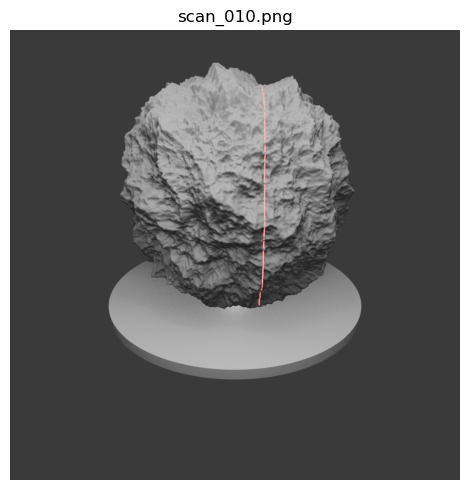

In [11]:
render_dir = ROOT / paths["input_dir"]
renders = sorted(render_dir.glob("scan_*.png"))

print(f"render dir: {render_dir}")
print(f"frames:     {len(renders)} / {config['disk']['n_frames']}")

assert renders, f"No rendered frames found in {render_dir}"

frame = min(10, len(renders) - 1)
image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(renders[frame].name)
plt.axis("off")
plt.tight_layout()

## 2. Laser Stripe Extraction

Dataset: asteroid
scan_000: 504 stripe points
scan_001: 491 stripe points
scan_002: 507 stripe points
scan_003: 477 stripe points
scan_004: 488 stripe points
scan_005: 487 stripe points
scan_006: 496 stripe points
scan_007: 523 stripe points
scan_008: 529 stripe points
scan_009: 520 stripe points
scan_010: 482 stripe points
scan_011: 486 stripe points
scan_012: 478 stripe points
scan_013: 496 stripe points
scan_014: 501 stripe points
scan_015: 507 stripe points
scan_016: 477 stripe points
scan_017: 481 stripe points
scan_018: 459 stripe points
scan_019: 470 stripe points
scan_020: 498 stripe points
scan_021: 475 stripe points
scan_022: 503 stripe points
scan_023: 500 stripe points
scan_024: 513 stripe points
scan_025: 525 stripe points
scan_026: 503 stripe points
scan_027: 499 stripe points
scan_028: 482 stripe points
scan_029: 476 stripe points
scan_030: 485 stripe points
scan_031: 479 stripe points
scan_032: 513 stripe points
scan_033: 489 stripe points
scan_034: 508 stripe points
sc

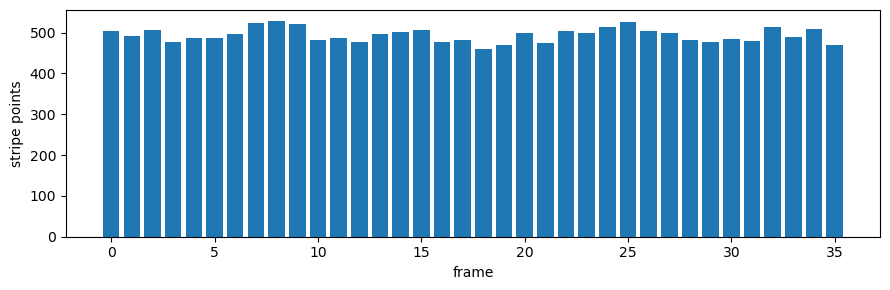

In [12]:
subprocess.run([sys.executable, "extract_stripes.py"], cwd=ROOT, check=True)

masks = sorted((ROOT / paths["stripe_masks_dir"]).glob("scan_*.png"))
coords = sorted((ROOT / paths["stripe_coords_dir"]).glob("scan_*.npy"))
counts = np.array([len(np.load(path)) for path in coords])

print(f"masks:  {len(masks)}")
print(f"coords: {len(coords)}")
print(f"stripe points per frame: min {counts.min()}  mean {counts.mean():.1f}  max {counts.max()}")

plt.figure(figsize=(9, 3))
plt.bar(range(len(counts)), counts)
plt.xlabel("frame")
plt.ylabel("stripe points")
plt.tight_layout()

## 3. Centerline Check

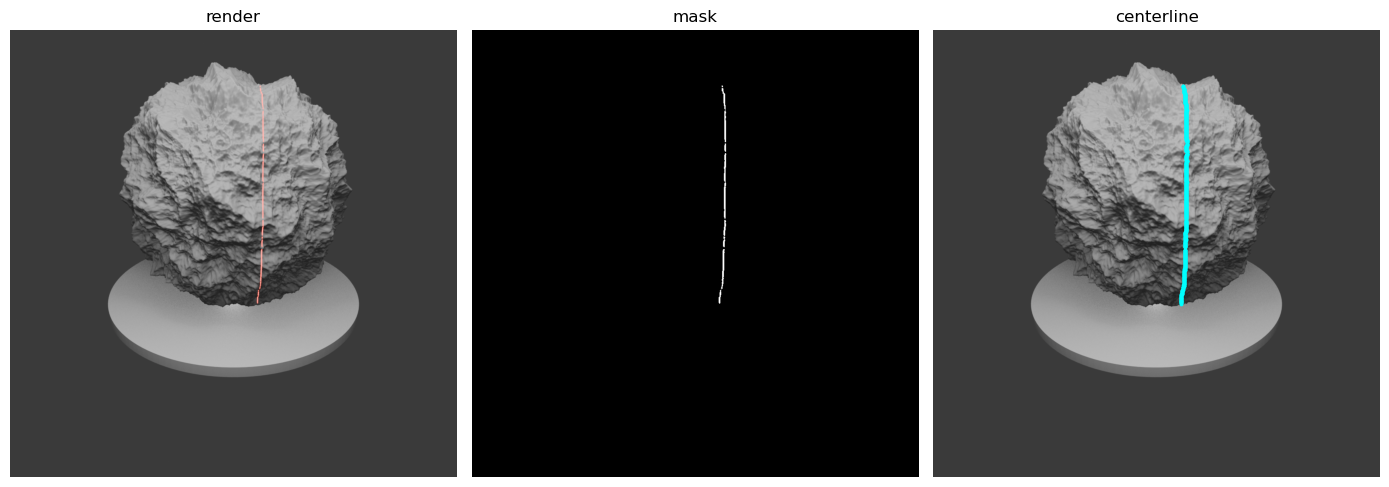

In [13]:
frame = min(10, len(renders) - 1)

image = cv2.cvtColor(cv2.imread(str(renders[frame])), cv2.COLOR_BGR2RGB)
mask = cv2.imread(str(masks[frame]), cv2.IMREAD_GRAYSCALE)
centerline = np.load(coords[frame])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("render")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("mask")
axes[2].imshow(image)
axes[2].scatter(centerline[:, 1], centerline[:, 0], s=3, c="cyan")
axes[2].set_title("centerline")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

## 4. Point Cloud Reconstruction

points: 17777
saved:  /Users/delia/uni/computer_vision/Project/ComputerVision/point_cloud_asteroid.ply
min:    [-1.6570183  -1.6021515   0.13473138]
max:    [1.6881986 1.6080037 3.4655094]
mean:   [2.1664961e-03 3.5044195e-03 2.1766355e+00]


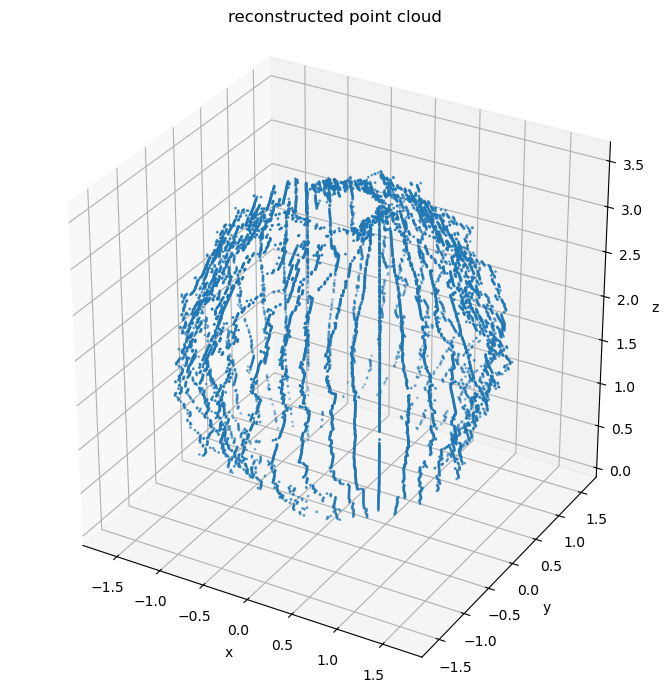

In [14]:
points = reconstruct(config)
point_cloud_path = ROOT / paths["point_cloud"]
save_ply(points, point_cloud_path)

print(f"points: {len(points)}")
print(f"saved:  {point_cloud_path}")
print(f"min:    {points.min(axis=0)}")
print(f"max:    {points.max(axis=0)}")
print(f"mean:   {points.mean(axis=0)}")

plot_points(points, "reconstructed point cloud")

## 5. Poisson Surface Reconstruction

mesh vertices:  45069
mesh triangles: 89367
saved:          /Users/delia/uni/computer_vision/Project/ComputerVision/mesh_asteroid.ply


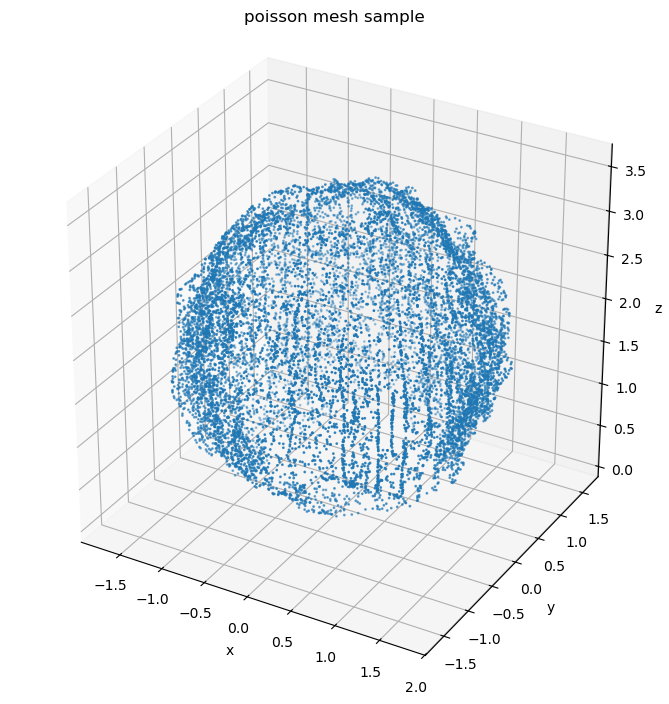

In [15]:
mesh_points = points[np.isfinite(points).all(axis=1)]
pcd = point_cloud_from_array(mesh_points)

voxel_size = 0.02
pcd = pcd.voxel_down_sample(voxel_size)
pcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.20, max_nn=30)
)
pcd.orient_normals_consistent_tangent_plane(30)

mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd,
    depth=8,
    scale=1.15,
    linear_fit=False
)

densities = np.asarray(densities)
mesh.remove_vertices_by_mask(densities < np.quantile(densities, 0.03))
mesh.compute_vertex_normals()

mesh_path = ROOT / paths["reconstructed_mesh"]
o3d.io.write_triangle_mesh(str(mesh_path), mesh)

print(f"mesh vertices:  {len(mesh.vertices)}")
print(f"mesh triangles: {len(mesh.triangles)}")
print(f"saved:          {mesh_path}")

mesh_sample = np.asarray(mesh.sample_points_uniformly(number_of_points=min(12000, len(mesh.vertices) * 2)).points)
plot_points(mesh_sample, "poisson mesh sample")

## 6. Chamfer Distance

{
  "reconstruction_to_ground_truth_mean": 0.09188017397602491,
  "ground_truth_to_reconstruction_mean": 0.09334662622933237,
  "chamfer_l1_mean": 0.09261340010267864,
  "chamfer_l2_mean": 0.01462279418483988,
  "reconstruction_to_ground_truth_p95": 0.22041386341632174,
  "ground_truth_to_reconstruction_p95": 0.2710857837510919,
  "dataset": "asteroid",
  "sample_count": 30000,
  "ground_truth_aligned_by_bbox": true
}
saved: /Users/delia/uni/computer_vision/Project/ComputerVision/metrics_asteroid.json


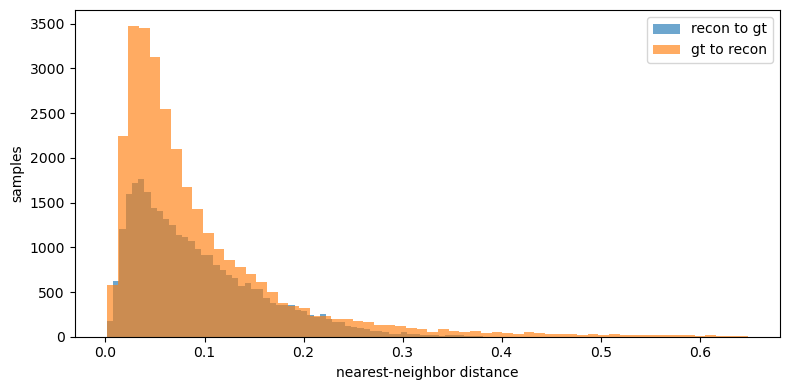

In [16]:
def sample_mesh_points(mesh_file, count):
    mesh = o3d.io.read_triangle_mesh(str(mesh_file))
    if mesh.is_empty() or len(mesh.triangles) == 0:
        raise ValueError(f"Mesh is empty or has no faces: {mesh_file}")
    mesh.compute_vertex_normals()
    return np.asarray(mesh.sample_points_uniformly(number_of_points=count).points)


def bbox_align(source, target):
    source_min = source.min(axis=0)
    source_max = source.max(axis=0)
    target_min = target.min(axis=0)
    target_max = target.max(axis=0)

    source_center = 0.5 * (source_min + source_max)
    target_center = 0.5 * (target_min + target_max)
    source_scale = np.max(source_max - source_min)
    target_scale = np.max(target_max - target_min)

    if source_scale == 0:
        return source.copy()

    return (source - source_center) * (target_scale / source_scale) + target_center


def directional_distances(source, target):
    source_pcd = point_cloud_from_array(source)
    target_pcd = point_cloud_from_array(target)
    return np.asarray(source_pcd.compute_point_cloud_distance(target_pcd))


def chamfer_metrics(reconstruction, ground_truth):
    d_recon_gt = directional_distances(reconstruction, ground_truth)
    d_gt_recon = directional_distances(ground_truth, reconstruction)
    return {
        "reconstruction_to_ground_truth_mean": float(d_recon_gt.mean()),
        "ground_truth_to_reconstruction_mean": float(d_gt_recon.mean()),
        "chamfer_l1_mean": float(0.5 * (d_recon_gt.mean() + d_gt_recon.mean())),
        "chamfer_l2_mean": float(0.5 * ((d_recon_gt ** 2).mean() + (d_gt_recon ** 2).mean())),
        "reconstruction_to_ground_truth_p95": float(np.percentile(d_recon_gt, 95)),
        "ground_truth_to_reconstruction_p95": float(np.percentile(d_gt_recon, 95))
    }, d_recon_gt, d_gt_recon


mesh_path = ROOT / paths["reconstructed_mesh"]
ground_truth_path = ROOT / paths["ground_truth_mesh"]
metrics_path = ROOT / paths["metrics"]

sample_count = 30000
align_ground_truth_to_reconstruction = True

if not ground_truth_path.exists():
    print(f"Missing ground truth mesh: {ground_truth_path}")
    print("Export the original Blender object to that path, then rerun this cell.")
else:
    reconstruction_sample = sample_mesh_points(mesh_path, sample_count)
    ground_truth_sample = sample_mesh_points(ground_truth_path, sample_count)

    if align_ground_truth_to_reconstruction:
        ground_truth_sample = bbox_align(ground_truth_sample, reconstruction_sample)

    metrics, d_recon_gt, d_gt_recon = chamfer_metrics(reconstruction_sample, ground_truth_sample)
    metrics["dataset"] = dataset_name
    metrics["sample_count"] = sample_count
    metrics["ground_truth_aligned_by_bbox"] = align_ground_truth_to_reconstruction

    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    print(json.dumps(metrics, indent=2))
    print(f"saved: {metrics_path}")

    plt.figure(figsize=(8, 4))
    plt.hist(d_recon_gt, bins=60, alpha=0.65, label="recon to gt")
    plt.hist(d_gt_recon, bins=60, alpha=0.65, label="gt to recon")
    plt.xlabel("nearest-neighbor distance")
    plt.ylabel("samples")
    plt.legend()
    plt.tight_layout()